In [3]:
pip install xarray netcdf4 rioxarray matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [28]:
import xarray as xr
import matplotlib.pyplot as plt

### Uploading the files and printing the file details and variable details

In [48]:
et = xr.open_dataset(r"D:\Projects\GNR644 - Water Balance\Evapotranspiration\GLEAM_Evapotranspiration_resampled_NN.nc")
sm = xr.open_dataset(r"D:\Projects\GNR644 - Water Balance\Soil Moisture\SoilMoisture_Crop.nc")

print(et)
print(sm)

<xarray.Dataset> Size: 6MB
Dimensions:      (time: 300, lat: 67, lon: 75)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2000-01-31 2000-02-29 ... 2024-12-31
  * lat          (lat) float64 536B 8.15 8.4 8.65 8.9 ... 23.9 24.15 24.4 24.65
  * lon          (lon) float64 600B 72.55 72.8 73.05 73.3 ... 90.55 90.8 91.05
Data variables:
    spatial_ref  int64 8B ...
    ET           (time, lat, lon) float32 6MB ...
<xarray.Dataset> Size: 6MB
Dimensions:      (time: 300, lat: 67, lon: 75)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2024-12-01
  * lat          (lat) float32 268B 24.62 24.38 24.12 ... 8.625 8.375 8.125
  * lon          (lon) float32 300B 72.62 72.88 73.12 ... 90.62 90.88 91.12
Data variables:
    spatial_ref  int64 8B ...
    sm           (time, lat, lon) float32 6MB ...


In [49]:
et_var = et['ET']
print("Evapotranspiration", et.data_vars)

sm_var = sm['sm']
print("Soil Moisture", sm.data_vars)

Evapotranspiration Data variables:
    spatial_ref  int64 8B ...
    ET           (time, lat, lon) float32 6MB ...
Soil Moisture Data variables:
    spatial_ref  int64 8B ...
    sm           (time, lat, lon) float32 6MB ...


### Plotting the Time Series map using the mean of Peninsular Basin

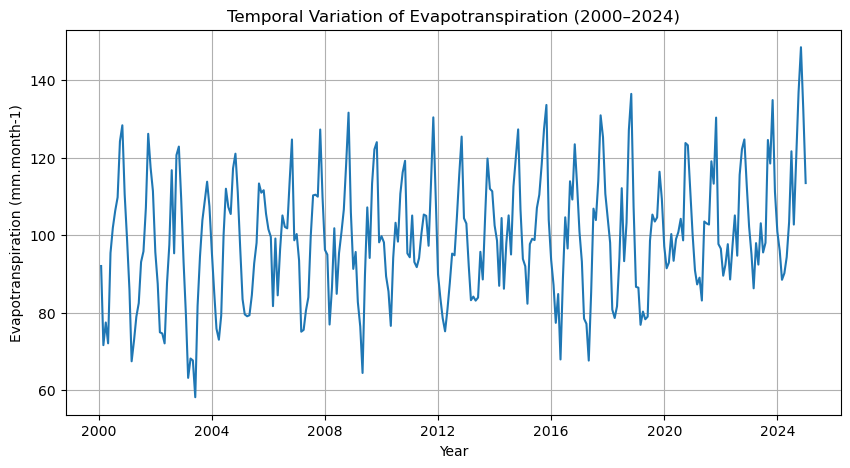

In [50]:
et_ts = et_var.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

et_ts.plot(label='Evapotranspiration')

plt.title("Temporal Variation of Evapotranspiration (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Evapotranspiration (mm.month-1)")
plt.grid(True)

plt.show()

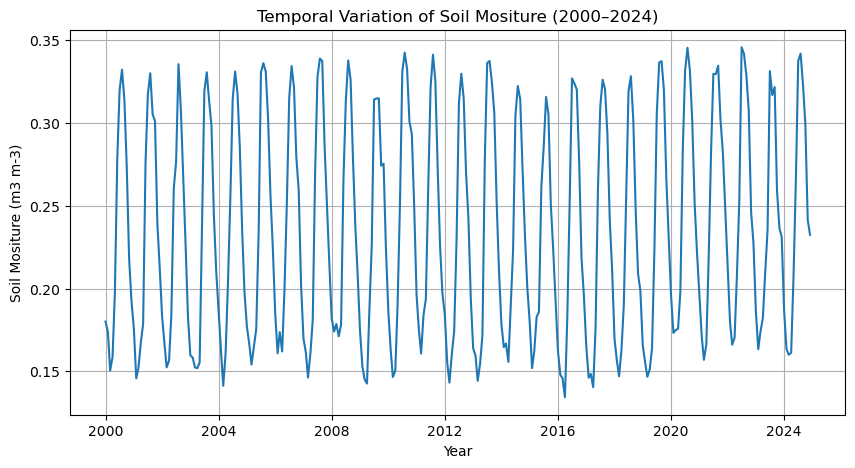

In [51]:
sm_ts = sm_var.mean(dim=['lat','lon'])
plt.figure(figsize=(10,5))

sm_ts.plot(label='Soil Moisture')

plt.title("Temporal Variation of Soil Mositure (2000–2024)")
plt.xlabel("Year")
plt.ylabel("Soil Mositure (m3 m-3)")
plt.grid(True)

plt.show()

### Grouping the mean by Month

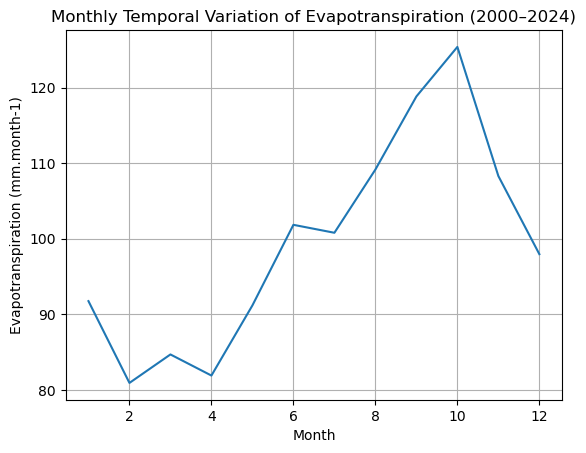

In [52]:
et_season = et_ts.groupby('time.month').mean()
et_season.plot(label='ET')
plt.title("Monthly Temporal Variation of Evapotranspiration (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Evapotranspiration (mm.month-1)")
plt.grid(True)

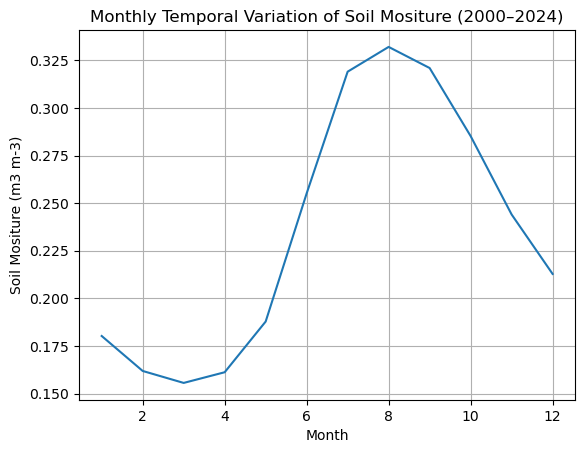

In [53]:
sm_season = sm_ts.groupby('time.month').mean()
sm_season.plot(label='Soil Moisture')
plt.title("Monthly Temporal Variation of Soil Mositure (2000–2024)")
plt.xlabel("Month")
plt.ylabel("Soil Mositure (m3 m-3)")
plt.grid(True)

### Trend Analysis

In [54]:
import numpy as np
from scipy.stats import linregress

time_et = np.arange(len(et_ts))

slope, intercept, r, p, std = linregress(time_et, et_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 0.03918854251612725
p-value: 0.00016634826851543596


Since the slope is greater than 0, it is increasing

In [55]:
time_sm = np.arange(len(sm_ts))

slope, intercept, r, p, std = linregress(time_sm, sm_ts)

print("Trend slope:", slope)
print("p-value:", p)

Trend slope: 5.044874988302502e-05
p-value: 0.25274148325872076


It has a increasing trend

### Pixel wise Trend using MK Test (not like previous one where we perfrom MK Test month wise, here we perform MK Test Overall)

In [56]:
def trend_calc(y):
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x, y)
    return slope

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Evapotranspiration from 2000 to 2024')

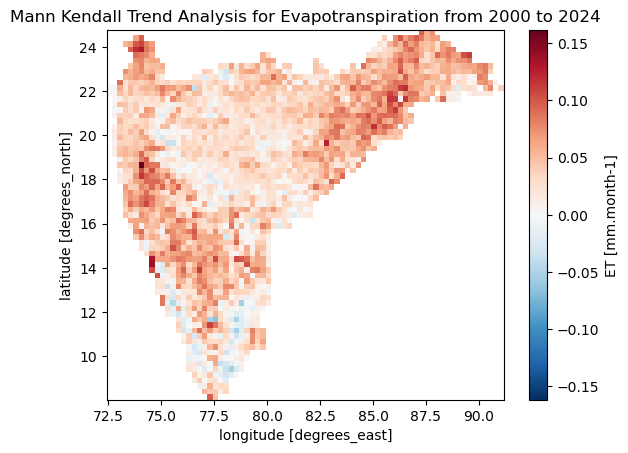

In [57]:
et_trend = xr.apply_ufunc(
    trend_calc,
    et_var,
    input_core_dims=[['time']],
    vectorize=True
)

et_trend.plot()
plt.title("Mann Kendall Trend Analysis for Evapotranspiration from 2000 to 2024")

Text(0.5, 1.0, 'Mann Kendall Trend Analysis for Soil moisture from 2000 to 2024')

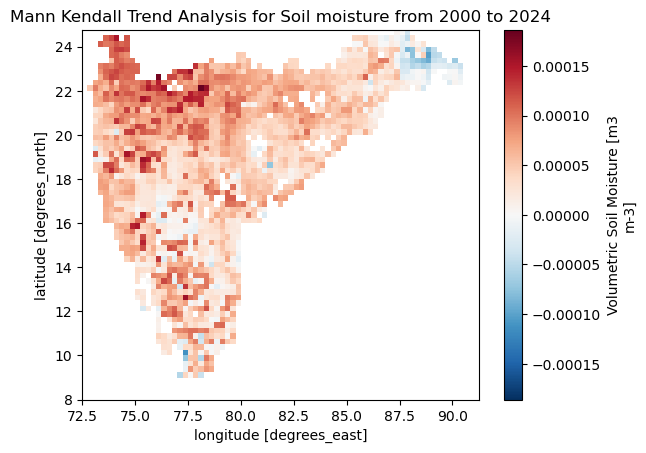

In [58]:
sm_trend = xr.apply_ufunc(
    trend_calc,
    sm_var,
    input_core_dims=[['time']],
    vectorize=True
)

sm_trend.plot()
plt.title("Mann Kendall Trend Analysis for Soil moisture from 2000 to 2024")

### Anomaly to find Drought years

Text(0.5, 1.0, 'Anomaly TSA Plot for Evapotranspiration')

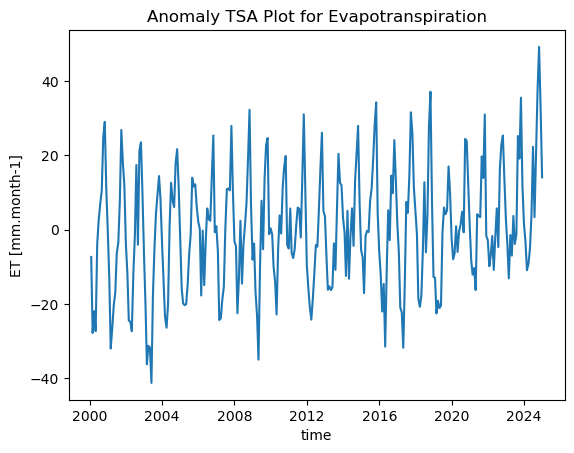

In [59]:
et_mean = et_ts.mean()
et_anomaly = et_ts - et_mean

et_anomaly.plot()
plt.title("Anomaly TSA Plot for Evapotranspiration") 

Text(0.5, 1.0, 'Anomaly TSA Plot for Soil Moisture')

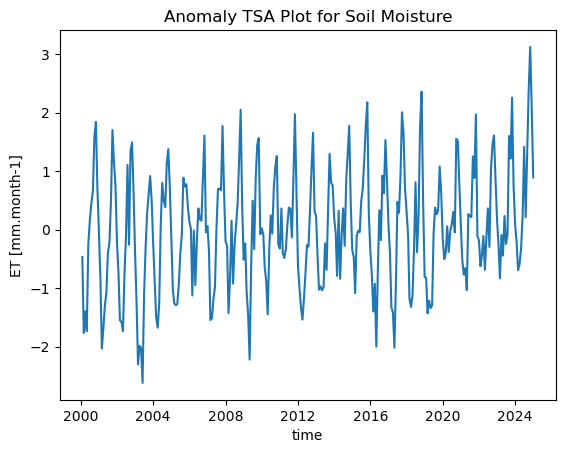

In [60]:
et_std = et_ts.std()
et_std_anomaly = (et_ts - et_mean) / et_std
et_std_anomaly.plot()
plt.title("Anomaly TSA Plot for Soil Moisture") 